# Linear Models - S&P 500 Equity Straddles

S&P 500 equity options give the widest cross-section in the book: individual
equity straddles carrying 52 features (47 financial features from
`03_financial_features`, 4 GARCH/SV features from `04_model_based_features`,
and calendar days to expiry from `02_labels`).
The label is the return to expiry (`ret_to_expiry`), and the prediction problem is
which stocks' options are mispriced relative to realized volatility. Linear models
test whether systematic variance-risk-premium (VRP) patterns are detectable with
simple regularized regression before the non-linear models that follow.

**Learning Objectives**:
- Quantify linear predictability of return-to-expiry from IV and VRP features
- Compare L1 (Lasso) vs L2 (Ridge) regularization on a dense, correlated feature set
- Assess fold stability across the two walk-forward validation folds
- Generate backtesting-ready predictions for downstream Ch16 simulation

**Book Reference**: Chapter 11, Section 11.2 (Regularized Linear Models)

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) (47 features), [`04_model_based_features`](04_model_based_features.ipynb) (4 GARCH/SV features)

In [1]:
"""Linear Models - walk-forward cross-validation."""

import hashlib
import os
import time
import warnings
from datetime import UTC, datetime
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
import yaml
from IPython.display import Markdown, display
from ml4t.diagnostic.metrics import compute_ic_uncertainty, cross_sectional_ic_series
from scipy.stats import norm
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, LogisticRegression, Ridge

In [2]:
from case_studies.utils.registry import (
    build_training_spec,
    load_prediction_metrics,
    load_prediction_sets,
    prediction_hash_from_parts,
    register_prediction_set,
    register_training_run,
    training_hash_from_spec,
    training_run_status,
)
from utils.artifact_specs import load_feature_spec, load_label_spec, resolve_storage_path
from utils.cv_splits import generate_cv_splits
from utils.modeling import (
    ConfigError,
    load_configs,
    load_modeling_dataset,
    prepare_cv_folds,
    resolve_linear_params,
)
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

In [3]:
SEED = 42
CASE_STUDY_ID = "sp500_options"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
FORCE_RETRAIN = False  # Set True to retrain configs that already have complete hashes
PREDICTION_SPLIT = "validation"
TRAINING_IDENTITY_VERSION = "sp500-options-linear-v3"
TRAIN_SAMPLE_FRAC = 1.0  # <1.0 subsamples training rows per fold (val is never sampled). Use for memory-constrained runs on large datasets.
MAX_FOLDS = 0
IC_DEPENDENCE_SESSIONS = 21
IC_HAC_LAG = IC_DEPENDENCE_SESSIONS - 1
IC_UNCERTAINTY_ALIASES = {
    "mean_ic": "ic_mean_daily",
    "std_ic": "ic_std_daily",
    "n_days": "ic_n_days",
    "pct_positive": "ic_pct_positive",
    "se_naive": "ic_se_naive",
    "ci_naive_lower": "ic_naive_lo",
    "ci_naive_upper": "ic_naive_hi",
    "se_hac": "ic_se_hac",
    "ci_hac_lower": "ic_ci_lo",
    "ci_hac_upper": "ic_ci_hi",
    "t_hac": "ic_t_hac",
    "p_hac": "ic_p_hac",
    "hac_lag": "ic_hac_lag",
    "ci_boot_lower": "ic_boot_lo",
    "ci_boot_upper": "ic_boot_hi",
    "boot_block_size": "ic_boot_block",
}

warnings.filterwarnings("ignore")
set_global_seeds(SEED)

In [4]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
if not PRIMARY_LABEL:
    setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
    PRIMARY_LABEL = setup["labels"]["primary"]

During preservation runs, the frozen registry remains read-only. The output
tree must be a real directory hierarchy, not a symlink or hard-link alias to
any canonical registry path.

In [5]:
def _same_inode(left: Path, right: Path) -> bool:
    """Return whether two existing paths address the same filesystem object."""
    return left.exists() and right.exists() and os.path.samefile(left, right)

In [6]:
def _assert_isolated_path(path: Path, root: Path, canonical: Path) -> None:
    """Reject symlink, escape, and hard-link aliases for one write path."""
    if path.is_symlink():
        raise RuntimeError(f"Isolated write path is a symlink: {path.name}")
    resolved = path.resolve()
    if resolved != root and root not in resolved.parents:
        raise RuntimeError(f"Isolated write path resolves outside ML4T_OUTPUT_DIR: {path.name}")
    if path.is_file() and path.stat().st_nlink > 1:
        raise RuntimeError(f"Isolated regular file has multiple hard links: {path.name}")
    if _same_inode(path, canonical):
        raise RuntimeError(f"Isolated write path aliases the canonical registry: {path.name}")

In [7]:
def _require_isolated_registry(case_dir: Path) -> None:
    """Fail closed when a preservation run could reach the frozen registry."""
    if os.environ.get("ML4T_PRESERVE_REGISTRY") != "1":
        return
    output_root = os.environ.get("ML4T_OUTPUT_DIR")
    if not output_root:
        raise RuntimeError("Preservation runs require ML4T_OUTPUT_DIR")
    expected = Path(output_root).absolute() / CASE_STUDY_ID
    if case_dir.absolute() != expected or case_dir.is_symlink():
        raise RuntimeError("Case-study output is not a real isolated directory")
    canonical = Path(
        os.environ.get(
            "ML4T_CANONICAL_CASE_DIR",
            Path.home() / "ml4t/code/case_studies" / CASE_STUDY_ID,
        )
    ).resolve()
    if _same_inode(case_dir, canonical):
        raise RuntimeError("Case-study output aliases the canonical case directory")
    run_log = case_dir / "run_log"
    _assert_isolated_path(run_log, expected, canonical / "run_log")
    run_log.mkdir(parents=True, exist_ok=True)
    for name in ("training", "predictions"):
        child = run_log / name
        _assert_isolated_path(child, run_log, canonical / "run_log" / name)
        child.mkdir(exist_ok=True)
    for child in run_log.rglob("*"):
        relative = child.relative_to(run_log)
        _assert_isolated_path(child, run_log, canonical / "run_log" / relative)
        if _same_inode(child, canonical / "run_log/registry.db"):
            raise RuntimeError(f"Isolated write path aliases canonical registry inode: {relative}")

In [8]:
_require_isolated_registry(CASE_DIR)

## 1. Load Data and Model Configs

Model configurations are defined in `config/training/{label}.yaml`. Each entry
references a preset in `config/` - a complete specification of
the sklearn class and its constructor parameters. To modify the grid,
edit the label config file: comment out presets or add new ones.

The temporal artifact is keyed by both security and estimator fold. These
guards reject ambiguous keys before any preprocessing can turn a missing or
misassigned estimate into a plausible imputed value.

In [9]:
def _validate_temporal_keys(
    temporal: pl.DataFrame,
    date_col: str,
    entity_col: str,
    temporal_features: list[str],
) -> None:
    """Reject incomplete or ambiguous fold-specific temporal keys."""
    keys = [date_col, entity_col, "fold"]
    missing = set(keys + temporal_features).difference(temporal.columns)
    if missing:
        raise ValueError(f"Temporal artifact is missing columns: {sorted(missing)}")
    null_keys = temporal.select(pl.any_horizontal([pl.col(key).is_null() for key in keys])).sum()[
        0, 0
    ]
    if null_keys:
        raise ValueError(f"Temporal artifact has {null_keys} rows with null keys")
    duplicates = temporal.group_by(keys).len().filter(pl.col("len") > 1).height
    if duplicates:
        raise ValueError(f"Temporal artifact has {duplicates} duplicate fold-specific keys")

Fold numbering is part of the statistical contract. The canonical splitter
numbers the most recent validation window as fold 0 and steps backward. The
holdout estimator (`fold=-1`) is never a cross-validation input.

In [10]:
def _validate_cv_splits(cv_splits: list[dict], holdout_start: str) -> None:
    """Reject inverted, overlapping, or holdout-contaminated CV windows."""
    fold_ids = [int(split["fold"]) for split in cv_splits]
    if fold_ids != list(range(len(cv_splits))):
        raise ValueError(f"Canonical CV fold IDs must be 0..N-1, got {fold_ids}")
    holdout = pd.Timestamp(holdout_start)
    for split in cv_splits:
        train_end = pd.Timestamp(split["train_end"])
        val_start = pd.Timestamp(split["val_start"])
        val_end = pd.Timestamp(split["val_end"])
        if train_end >= val_start:
            raise ValueError(f"Fold {split['fold']} training overlaps validation")
        if val_end >= holdout:
            raise ValueError(f"Fold {split['fold']} reaches the sealed holdout")

Return-to-expiry labels are known only on the option expiry date. A 2020
decision whose expiry falls in 2021 therefore uses holdout information and is
excluded from model selection even though its feature timestamp is pre-holdout.

In [11]:
def _seal_label_endpoints(
    dataset: pl.DataFrame,
    date_col: str,
    holdout_start: str,
) -> pl.DataFrame:
    """Keep only rows whose full label endpoint precedes the holdout."""
    if "dte_calendar" not in dataset.columns:
        raise ValueError("Return-to-expiry labels require dte_calendar")
    if dataset["dte_calendar"].null_count():
        raise ValueError("Return-to-expiry labels have null expiry horizons")
    holdout = pd.Timestamp(holdout_start).date()
    sealed = dataset.with_columns(
        (pl.col(date_col) + pl.duration(days=pl.col("dte_calendar"))).alias("_label_end")
    )
    if sealed.filter(pl.col("dte_calendar") < 0).height:
        raise ValueError("Return-to-expiry labels have negative expiry horizons")
    return sealed.filter(pl.col("_label_end") < holdout).drop("_label_end")

Each available temporal estimate is joined on `timestamp`, `symbol`, and
`fold`, so an estimator fitted for another window cannot enter the split.
Symbols without enough return history may lack an estimate; at least 95%
row coverage is required before train-only imputation handles those gaps.

In [12]:
def _align_temporal_fold(
    base: pl.DataFrame,
    temporal: pl.DataFrame,
    split: dict,
    date_col: str,
    entity_col: str,
    temporal_features: list[str],
) -> pl.DataFrame:
    """Join one estimator fold to its exact training and validation rows."""
    fold_id = int(split["fold"])
    if fold_id < 0:
        raise ValueError("Holdout temporal estimates cannot enter cross-validation")
    bounds = {
        name: pd.Timestamp(split[name]).date() if base.schema[date_col] == pl.Date else split[name]
        for name in ("train_start", "train_end", "val_start", "val_end")
    }
    train = pl.col(date_col).is_between(bounds["train_start"], bounds["train_end"], closed="both")
    val = pl.col(date_col).is_between(bounds["val_start"], bounds["val_end"], closed="both")
    rows = base.filter(train | val).with_columns(pl.lit(fold_id).alias("fold"))
    keys = [date_col, entity_col, "fold"]
    estimates = temporal.filter(pl.col("fold") == fold_id).select(
        [*keys, *temporal_features, pl.lit(1).alias("_temporal_match")]
    )
    aligned = rows.join(estimates, on=keys, how="left", validate="1:1")
    coverage = 1.0 - (missing := aligned["_temporal_match"].null_count()) / len(aligned)
    message = f"Fold {fold_id} is missing {missing} temporal row matches ({coverage:.1%} coverage)"
    if coverage < 0.95:
        raise ValueError(message)
    if missing:
        print(f"  {message}; train-only imputation will fill unavailable estimates")
    invalid = aligned.filter(pl.col("_temporal_match").is_not_null()).select(
        pl.any_horizontal(
            [pl.col(name).is_null() | pl.col(name).is_infinite() for name in temporal_features]
        ).sum()
    )[0, 0]
    if invalid:
        raise ValueError(f"Fold {fold_id} has {invalid} null or nonfinite temporal rows")
    return aligned.drop("_temporal_match")

Completeness is defined by the endpoint-sealed validation design, not by the
best coverage any model happens to produce. The expected key and IC-date sets
are derived once from the prepared folds and become fixed validation oracles.

In [13]:
def _expected_prediction_contract(
    prepared_folds: list[dict],
    join_cols: list[str],
    date_col: str,
    entity_col: str,
) -> tuple[pl.DataFrame, set]:
    """Build exact validation keys and eligible IC dates from prepared folds."""
    frames = []
    for fold in prepared_folds:
        if not np.isfinite(fold["y_val"]).all():
            raise ValueError(f"Fold {fold['fold']} has nonfinite validation labels")
        frame = pl.from_pandas(fold["meta"][join_cols]).with_columns(
            pl.lit(int(fold["fold"])).alias("fold"),
            pl.Series("actual", fold["y_val"]),
        )
        frames.append(frame)
    keys = [*join_cols, "fold"]
    expected = pl.concat(frames).sort(keys)
    if expected.select(pl.any_horizontal([pl.col(key).is_null() for key in keys])).sum()[0, 0]:
        raise ValueError("Expected validation keys contain nulls")
    if expected.group_by(keys).len().filter(pl.col("len") > 1).height:
        raise ValueError("Expected validation keys are not unique")
    eligible_dates = set(
        expected.group_by(date_col)
        .agg(pl.col(entity_col).n_unique().alias("n_entities"))
        .filter(pl.col("n_entities") >= 5)[date_col]
        .to_list()
    )
    if not eligible_dates:
        raise ValueError("Expected validation design has no eligible IC dates")
    return expected, eligible_dates

In [14]:
def _validate_actual_values(
    predictions: pl.DataFrame,
    expected: pl.DataFrame,
    keys: list[str],
) -> None:
    """Require cached targets to match the endpoint-sealed labels."""
    expected_actual = expected.select([*keys, pl.col("actual").alias("_expected_actual")])
    actual_check = predictions.select([*keys, "actual"]).join(expected_actual, on=keys, how="left")
    if not np.allclose(
        actual_check["actual"].to_numpy(),
        actual_check["_expected_actual"].to_numpy(),
        rtol=1e-12,
        atol=1e-12,
    ):
        raise ValueError("Cached actual values differ from endpoint-sealed labels")

In [15]:
def _validate_prediction_keys(
    predictions: pl.DataFrame,
    expected: pl.DataFrame,
    join_cols: list[str],
) -> pl.DataFrame:
    """Require exact, unique, finite prediction coverage."""
    keys = [*join_cols, "fold"]
    required = set(keys + ["prediction", "actual"])
    missing = required.difference(predictions.columns)
    if missing:
        raise ValueError(f"Predictions are missing columns: {sorted(missing)}")
    casts = {
        key: expected.schema[key] for key in keys if predictions.schema[key] != expected.schema[key]
    }
    if casts:
        predictions = predictions.cast(casts)
    nulls = predictions.select(
        pl.any_horizontal([pl.col(name).is_null() for name in required]).sum()
    )[0, 0]
    nonfinite = predictions.select(
        pl.any_horizontal([pl.col(name).is_infinite() for name in ("prediction", "actual")]).sum()
    )[0, 0]
    if nulls or nonfinite:
        raise ValueError(f"Predictions contain {nulls} null and {nonfinite} nonfinite rows")
    if predictions.group_by(keys).len().filter(pl.col("len") > 1).height:
        raise ValueError("Prediction keys are not unique")
    actual_keys = predictions.select(keys)
    missing_keys = expected.join(actual_keys, on=keys, how="anti").height
    extra_keys = actual_keys.join(expected, on=keys, how="anti").height
    if missing_keys or extra_keys:
        raise ValueError(f"Prediction coverage differs: missing={missing_keys}, extra={extra_keys}")
    _validate_actual_values(predictions, expected, keys)
    return predictions.sort(keys)

In [16]:
def _compute_complete_daily_ic(
    predictions: pl.DataFrame,
    expected_dates: set,
    date_col: str,
    entity_col: str,
) -> dict[str, float | int]:
    """Compute daily IC only when every expected date yields a finite value."""
    ordered = predictions.sort([date_col, entity_col])
    daily = cross_sectional_ic_series(
        ordered,
        ordered,
        pred_col="prediction",
        ret_col="actual",
        date_col=date_col,
        entity_col=entity_col,
        method="spearman",
        min_obs=5,
    ).sort(date_col)
    complete_daily = daily.drop_nulls("ic").filter(pl.col("ic").is_finite())
    actual_dates = set(complete_daily[date_col].to_list())
    if actual_dates != expected_dates:
        missing = len(expected_dates - actual_dates)
        extra = len(actual_dates - expected_dates)
        raise ValueError(f"Daily IC coverage differs: missing={missing}, extra={extra}")
    values = complete_daily["ic"].to_numpy()
    return {
        "ic_mean": float(np.mean(values)),
        "ic_std": float(np.std(values, ddof=1)),
        "ic_n_days": int(len(values)),
    }

The endpoint purge uses 35 calendar days, while inference follows the
observed 21-session median holding period established upstream. Newey-West
therefore uses 20 lags; the two horizons protect different contracts.

In [17]:
def _compute_ic_uncertainty_metrics(
    predictions: pl.DataFrame | pd.DataFrame,
    expected_dates: set,
    date_col: str,
    entity_col: str,
) -> dict[str, float | int]:
    """Compute daily-IC uncertainty under the 21-session dependence contract."""
    frame = predictions if isinstance(predictions, pl.DataFrame) else pl.from_pandas(predictions)
    daily = cross_sectional_ic_series(
        frame.sort([date_col, entity_col]),
        frame.sort([date_col, entity_col]),
        pred_col="prediction",
        ret_col="actual",
        date_col=date_col,
        entity_col=entity_col,
        method="spearman",
        min_obs=5,
    ).sort(date_col)
    complete = daily.drop_nulls("ic").filter(pl.col("ic").is_finite())
    if set(complete[date_col].to_list()) != expected_dates:
        raise ValueError("Uncertainty daily-IC dates differ from the validation contract")
    values = compute_ic_uncertainty(
        complete.select("ic"), horizon=IC_DEPENDENCE_SESSIONS, n_boot=1000
    )
    if int(values["hac_lag"]) != IC_HAC_LAG:
        raise ValueError("Daily-IC uncertainty did not use the required 20 HAC lags")
    critical = float(norm.ppf(0.975))
    values["ci_hac_lower"] = values["mean_ic"] - critical * values["se_hac"]
    values["ci_hac_upper"] = values["mean_ic"] + critical * values["se_hac"]
    values["p_hac"] = float(2 * norm.sf(abs(values["t_hac"])))
    return {target: values[source] for source, target in IC_UNCERTAINTY_ALIASES.items()}

In [18]:
def _modeling_artifact_paths(case_study_id: str, label: str) -> dict[str, Path]:
    """Resolve the three exact parquet inputs consumed by the modeling loader."""
    financial = load_feature_spec(case_study_id, "financial")
    temporal = load_feature_spec(case_study_id, "model_based")
    label_spec = load_label_spec(case_study_id, label)
    return {
        "financial": resolve_storage_path(case_study_id, financial, "features/financial.parquet"),
        "model_based": resolve_storage_path(
            case_study_id, temporal, "features/model_based.parquet"
        ),
        "label": resolve_storage_path(case_study_id, label_spec, f"labels/{label}.parquet"),
    }

In [19]:
def _artifact_identity(paths: dict[str, Path]) -> dict[str, dict[str, int | str]]:
    """Hash exact input bytes and reject files that change while being read."""
    identity = {}
    for name, path in sorted(paths.items()):
        before = path.stat()
        digest = hashlib.sha256()
        with path.open("rb") as stream:
            for chunk in iter(lambda: stream.read(1024 * 1024), b""):
                digest.update(chunk)
        after = path.stat()
        before_state = (before.st_dev, before.st_ino, before.st_size, before.st_mtime_ns)
        after_state = (after.st_dev, after.st_ino, after.st_size, after.st_mtime_ns)
        if before_state != after_state:
            raise RuntimeError(f"Input artifact changed while hashing: {name}")
        identity[name] = {"sha256": digest.hexdigest(), "size_bytes": after.st_size}
    return identity

In [20]:
def _evaluation_identity(
    cv_splits: list[dict], holdout_start: str, holdout_end: str, label_buffer: str
) -> dict:
    """Serialize every boundary that determines the validation design."""
    keys = ("train_start", "train_end", "val_start", "val_end")
    bounds = [
        {"fold": int(split["fold"]), **{key: pd.Timestamp(split[key]).isoformat() for key in keys}}
        for split in cv_splits
    ]
    return {
        "label_buffer": str(label_buffer),
        "holdout_start": pd.Timestamp(holdout_start).isoformat(),
        "holdout_end": pd.Timestamp(holdout_end).isoformat(),
        "splits": bounds,
    }

In [21]:
def _bind_training_identity(spec: dict, artifacts: dict, evaluation: dict, version: str) -> dict:
    """Bind a registry spec to exact data bytes and evaluation boundaries."""
    enriched = dict(spec)
    enriched["input_identity"] = {
        "version": version,
        "artifacts": artifacts,
        "evaluation": evaluation,
    }
    return enriched

In [22]:
ARTIFACT_PATHS = _modeling_artifact_paths(CASE_STUDY_ID, PRIMARY_LABEL)
ARTIFACT_HASHES = _artifact_identity(ARTIFACT_PATHS)
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)
if _artifact_identity(ARTIFACT_PATHS) != ARTIFACT_HASHES:
    raise RuntimeError("Modeling artifacts changed while loading")

raw_dataset = mds.dataset
feature_names = mds.feature_names
label_col = mds.label_col
date_col = mds.date_col
entity_col = mds.entity_cols[0] if mds.entity_cols else None
if entity_col is None:
    raise ValueError("S&P 500 options modeling requires a cross-sectional entity key")
canonical_splits = generate_cv_splits(
    raw_dataset,
    case_study_id=CASE_STUDY_ID,
    label_buffer=mds.label_buffer,
    date_col=date_col,
)
_validate_cv_splits(canonical_splits, setup["evaluation"]["holdout_start"])
splits = canonical_splits[: MAX_FOLDS or None]
dataset = _seal_label_endpoints(
    raw_dataset,
    date_col,
    setup["evaluation"]["holdout_start"],
)

print(f"Dataset: {len(dataset):,} rows × {len(feature_names)} features")
print(f"Label: {label_col} | Task: {mds.task_type} | Folds: {len(splits)}")

Dataset: 274,069 rows × 52 features
Label: ret_to_expiry | Task: regression | Folds: 2


In [23]:
configs = load_configs(CASE_STUDY_ID, PRIMARY_LABEL, family="linear")

print(f"{len(configs)} configs × {len(splits)} folds = {len(configs) * len(splits)} fits")
config_table = pl.DataFrame(
    {
        "configuration": [cfg["config_name"] for cfg in configs],
        "model": [cfg["model_class"] for cfg in configs],
        "parameters": [
            ", ".join(f"{key}={value}" for key, value in cfg["params"].items()) or "defaults"
            for cfg in configs
        ],
    }
)
config_table

28 configs × 2 folds = 56 fits


configuration,model,parameters
str,str,str
"""ridge_a1000.0""","""Ridge""","""alpha=1000.0"""
"""ridge_a10000.0""","""Ridge""","""alpha=10000.0"""
"""ridge_a100.0""","""Ridge""","""alpha=100.0"""
"""ridge_a1.0""","""Ridge""","""alpha=1.0"""
"""ridge_a10.0""","""Ridge""","""alpha=10.0"""
…,…,…
"""enet_f0.03""","""ElasticNet""","""alpha_frac=0.03, l1_ratio=0.5,…"
"""enet_f0.015""","""ElasticNet""","""alpha_frac=0.015, l1_ratio=0.5…"
"""enet_f0.35""","""ElasticNet""","""alpha_frac=0.35, l1_ratio=0.5,…"


## 2. Prepare CV Folds

Each fold first receives the temporal estimates fitted for that exact window.
Fold identity stays in the join key for both training and validation rows.
Only then does train-only median imputation and standardization fit on the
training slice and transform validation.

In [24]:
if mds.temporal_by_fold is None or not mds.temporal_feature_names:
    raise ValueError("Fold-specific temporal features are required")
temporal = pl.from_pandas(mds.temporal_by_fold)
_validate_temporal_keys(temporal, date_col, entity_col, mds.temporal_feature_names)
key_casts = {
    key: dataset.schema[key]
    for key in (date_col, entity_col)
    if temporal.schema[key] != dataset.schema[key]
}
if key_casts:
    temporal = temporal.cast(key_casts)

base_dataset = dataset.drop(mds.temporal_feature_names)
folds = []
for split in splits:
    aligned = _align_temporal_fold(
        base_dataset,
        temporal,
        split,
        date_col,
        entity_col,
        mds.temporal_feature_names,
    )
    prepared = prepare_cv_folds(
        aligned.to_pandas(),
        [split],
        feature_names,
        label_col,
        date_col,
        entity_col,
        train_sample_frac=TRAIN_SAMPLE_FRAC,
    )
    if len(prepared) != 1:
        raise ValueError(f"Fold {split['fold']} did not produce exactly one prepared split")
    folds.extend(prepared)

for f in folds:
    print(f"  Fold {f['fold']}: train={f['n_train']:,}  val={f['n_val']:,}")

  Fold 0 is missing 5775 temporal row matches (97.1% coverage); train-only imputation will fill unavailable estimates


  Fold 1 is missing 6702 temporal row matches (96.7% coverage); train-only imputation will fill unavailable estimates


  Fold 0: train=141,355  val=60,256
  Fold 1: train=125,902  val=76,852


In [25]:
expected_prediction_keys, expected_ic_dates = _expected_prediction_contract(
    folds,
    mds.join_cols,
    date_col,
    entity_col,
)
expected_ic_days = len(expected_ic_dates)
print(
    f"Complete validation coverage: {len(expected_prediction_keys):,} keys, {expected_ic_days} dates"
)

Complete validation coverage: 137,108 keys, 484 dates


## 3. Walk-Forward Cross-Validation

For each configuration, fit the model on each training fold and predict
the validation fold. Cross-sectional IC (Spearman rank correlation per
date, averaged) measures predictive quality.

In [26]:
MODEL_CLASSES = {
    "LinearRegression": LinearRegression,
    "Ridge": Ridge,
    "Lasso": Lasso,
    "ElasticNet": ElasticNet,
    "LogisticRegression": LogisticRegression,
}

Cache reuse is an exact reproduction path. A registry row is insufficient:
its hash, physical parquet, complete keys, daily IC dates, and stored daily
metrics must all agree with the current validation contract.

In [27]:
def _training_spec(cfg: dict) -> dict:
    """Build the exact registry specification for one configuration."""
    base = build_training_spec(
        cfg["family"],
        cfg["config_name"],
        label_col,
        n_folds=len(folds),
        train_sample_frac=TRAIN_SAMPLE_FRAC,
    )
    evaluation = _evaluation_identity(
        splits,
        setup["evaluation"]["holdout_start"],
        setup["evaluation"]["holdout_end"],
        mds.label_buffer,
    )
    artifact_hashes = ARTIFACT_HASHES
    return _bind_training_identity(
        base,
        artifact_hashes,
        evaluation,
        TRAINING_IDENTITY_VERSION,
    )

In [28]:
def _prediction_cache_path(prediction_hash: str) -> Path:
    """Resolve and recheck one physical prediction artifact."""
    path = CASE_DIR / "run_log/predictions" / prediction_hash / "predictions.parquet"
    if os.environ.get("ML4T_PRESERVE_REGISTRY") == "1":
        canonical = Path(
            os.environ.get(
                "ML4T_CANONICAL_CASE_DIR",
                Path.home() / "ml4t/code/case_studies" / CASE_STUDY_ID,
            )
        ).resolve()
        relative = path.relative_to(CASE_DIR / "run_log")
        _assert_isolated_path(path, CASE_DIR / "run_log", canonical / "run_log" / relative)
    return path

In [29]:
def _validate_cached_metrics(prediction_hash: str, recomputed: dict) -> None:
    """Require one finite daily-metric row matching the physical predictions."""
    metrics = load_prediction_metrics(CASE_STUDY_ID, prediction_hash=prediction_hash)
    numeric = {
        "ic_mean_daily",
        "ic_std_daily",
        "ic_n_days",
        "ic_se_hac",
        "ic_ci_lo",
        "ic_ci_hi",
        "ic_t_hac",
        "ic_p_hac",
        "ic_hac_lag",
    }
    required = numeric | {"prediction_hash"}
    if metrics.height != 1 or not required.issubset(metrics.columns):
        raise ValueError("cache has no unique complete daily-metric row")
    if metrics["prediction_hash"][0] != prediction_hash:
        raise ValueError("cache metric row has the wrong prediction hash")
    values = metrics.select(sorted(numeric)).row(0, named=True)
    if not all(np.isfinite(float(value)) for value in values.values()):
        raise ValueError("cache has nonfinite daily metrics")
    if not np.isclose(float(values["ic_n_days"]), expected_ic_days):
        raise ValueError("cache daily metric count differs from the validation contract")
    if int(values["ic_hac_lag"]) != IC_HAC_LAG:
        raise ValueError("cache HAC lag differs from the 21-session dependence contract")
    for name in numeric:
        current_name = {"ic_mean_daily": "ic_mean", "ic_std_daily": "ic_std"}.get(name, name)
        stored, current = values[name], recomputed[current_name]
        if not np.isclose(float(stored), float(current), rtol=1e-12, atol=1e-12):
            raise ValueError(f"cache {name} differs from physical predictions")

In [30]:
def _read_cached_result(cfg: dict, spec: dict, status) -> dict | None:
    """Return a fully validated cache hit, or None when retraining is required."""
    if FORCE_RETRAIN or not status.complete:
        return None
    training_hash = training_hash_from_spec(spec)
    rows = load_prediction_sets(CASE_STUDY_ID, training_hash=training_hash, split=PREDICTION_SPLIT)
    if rows.is_empty():
        return None
    if rows.height != 1:
        raise ValueError(f"{cfg['config_name']}: cache has {rows.height} validation rows")
    row = rows.row(0, named=True)
    if row.get("training_hash") != training_hash or row.get("split") != PREDICTION_SPLIT:
        raise ValueError(f"{cfg['config_name']}: cache hash or split mismatch")
    prediction_hash = row.get("prediction_hash")
    if not prediction_hash:
        raise ValueError(f"{cfg['config_name']}: cache has no prediction hash")
    if row.get("checkpoint_value") is not None or row.get("checkpoint_kind") not in (None, "final"):
        raise ValueError(f"{cfg['config_name']}: cache is not the final checkpoint")
    if prediction_hash != prediction_hash_from_parts(training_hash, None, PREDICTION_SPLIT):
        raise ValueError(f"{cfg['config_name']}: cache prediction hash is forged")
    path = _prediction_cache_path(str(prediction_hash))
    if not path.is_file():
        return None
    predictions = pl.read_parquet(path)
    predictions = _validate_prediction_keys(predictions, expected_prediction_keys, mds.join_cols)
    summary = _compute_complete_daily_ic(predictions, expected_ic_dates, date_col, entity_col)
    uncertainty = _compute_ic_uncertainty_metrics(
        predictions, expected_ic_dates, date_col, entity_col
    )
    _validate_cached_metrics(str(prediction_hash), {**summary, **uncertainty})
    return {
        "config": cfg,
        "training_hash": training_hash,
        "predictions": predictions.to_pandas(),
        **summary,
        "cached": True,
    }

Fresh training follows the same physical prediction contract as cache reuse.
Coefficients and validation rows are accumulated fold by fold, then the exact
combined daily IC series is recomputed once for ranking.

In [31]:
def _coefficient_rows(model, cfg: dict, fold_id: int) -> list[dict]:
    """Return feature and intercept coefficients for one fitted fold."""
    if not hasattr(model, "coef_"):
        return []
    coefficients = model.coef_.ravel() if model.coef_.ndim > 1 else model.coef_
    rows = [
        {
            "config_name": cfg["config_name"],
            "fold": fold_id,
            "feature": feature,
            "coefficient": float(value),
        }
        for feature, value in zip(feature_names, coefficients, strict=False)
    ]
    intercept = model.intercept_ if np.isscalar(model.intercept_) else model.intercept_[0]
    rows.append(
        {
            "config_name": cfg["config_name"],
            "fold": fold_id,
            "feature": "_intercept_",
            "coefficient": float(intercept),
        }
    )
    return rows

In [32]:
def _fit_fold(cfg: dict, model_class, fold: dict) -> tuple[pd.DataFrame, list[dict]] | None:
    """Fit and predict one fold; return None for an all-zero model."""
    try:
        params = resolve_linear_params(cfg, fold["X_train"], fold["y_train"])
        model = model_class(**params)
    except TypeError as error:
        raise ConfigError(f"Cannot create {cfg['config_name']}: {error}") from error
    model.fit(fold["X_train"], fold["y_train"])
    if hasattr(model, "coef_") and np.all(model.coef_ == 0):
        return None
    if mds.task_type == "classification" and hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(fold["X_val"])
        prediction = probabilities @ np.array(sorted(mds.class_values), dtype=np.float64)
    else:
        prediction = model.predict(fold["X_val"])
    frame = fold["meta"][mds.join_cols].copy()
    frame["fold"] = fold["fold"]
    frame["prediction"] = prediction
    frame["actual"] = fold["y_val"]
    return frame, _coefficient_rows(model, cfg, int(fold["fold"]))

In [33]:
def _fit_config(cfg: dict, model_class) -> dict:
    """Train one configuration and validate its complete prediction panel."""
    started_at = datetime.now(UTC).isoformat()
    start = time.perf_counter()
    prediction_frames = []
    coefficient_rows = []
    for fold in folds:
        fitted = _fit_fold(cfg, model_class, fold)
        if fitted is None:
            return {
                "config": cfg,
                "predictions": pd.DataFrame(),
                "degenerate": True,
                "started_at": started_at,
                "elapsed_s": time.perf_counter() - start,
            }
        fold_predictions, fold_coefficients = fitted
        prediction_frames.append(fold_predictions)
        coefficient_rows.extend(fold_coefficients)
    predictions = pd.concat(prediction_frames, ignore_index=True).sort_values(
        [date_col, entity_col]
    )
    prediction_pl = pl.from_pandas(predictions)
    prediction_pl = _validate_prediction_keys(
        prediction_pl, expected_prediction_keys, mds.join_cols
    )
    summary = _compute_complete_daily_ic(prediction_pl, expected_ic_dates, date_col, entity_col)
    return {
        "config": cfg,
        "predictions": predictions,
        "coefficients": coefficient_rows,
        "degenerate": False,
        "started_at": started_at,
        "elapsed_s": time.perf_counter() - start,
        **summary,
    }

In [34]:
results = []
for cfg in configs:
    model_class = MODEL_CLASSES.get(cfg["model_class"])
    if model_class is None:
        raise ConfigError(f"Unknown model class for {cfg['config_name']}: {cfg['model_class']}")
    spec = _training_spec(cfg)
    status = training_run_status(CASE_STUDY_ID, spec)
    try:
        result = _read_cached_result(cfg, spec, status)
    except (OSError, ValueError) as error:
        print(f"  {cfg['config_name']:25s}  RETRAIN - {error}")
        result = None
    if result is None:
        if status.partial:
            print(f"  {cfg['config_name']:25s}  RETRAIN - {status.summary()}")
        result = _fit_config(cfg, model_class)
    result["training_hash"] = training_hash_from_spec(spec)
    result["training_spec"] = spec
    results.append(result)
    if result.get("degenerate"):
        print(f"  {cfg['config_name']:25s}  SKIP - all coefficients zero")
    else:
        source = "cached" if result.get("cached") else f"{result['elapsed_s']:.1f}s"
        print(
            f"  {cfg['config_name']:25s}  IC={result['ic_mean']:+.4f} ± "
            f"{result['ic_std']:.4f}  ({expected_ic_days} dates, {source})"
        )

  ridge_a1000.0              IC=-0.0064 ± 0.0903  (484 dates, cached)
  ridge_a10000.0             IC=-0.0080 ± 0.0935  (484 dates, cached)


  ridge_a100.0               IC=-0.0056 ± 0.0901  (484 dates, cached)


  ridge_a1.0                 IC=-0.0053 ± 0.0902  (484 dates, cached)


  ridge_a10.0                IC=-0.0053 ± 0.0902  (484 dates, cached)


  ridge_a0.1                 IC=-0.0052 ± 0.0899  (484 dates, cached)
  ridge_a0.01                IC=-0.0051 ± 0.0896  (484 dates, cached)


...

  enet_f0.2                  IC=-0.0162 ± 0.0977  (484 dates, cached)


  enet_f0.08                 IC=-0.0112 ± 0.0931  (484 dates, cached)
  enet_f0.03                 IC=-0.0086 ± 0.0918  (484 dates, cached)


  enet_f0.015                IC=-0.0075 ± 0.0913  (484 dates, cached)


  enet_f0.35                 IC=-0.0158 ± 0.1093  (484 dates, cached)
  enet_f0.7                  IC=-0.0039 ± 0.1221  (484 dates, cached)


  enet_f0.85                 IC=-0.0043 ± 0.1217  (484 dates, cached)


## 4. Results Summary

Rank every complete config by mean daily cross-sectional IC across the combined
validation timeline. The two figures below then isolate the two regularization
axes: the full ranking and the Ridge penalty sweep.

In [35]:
active = [r for r in results if not r.get("degenerate")]
degenerate = [r for r in results if r.get("degenerate")]
expected_names = [cfg["config_name"] for cfg in configs]
result_names = [result["config"]["config_name"] for result in results]
if result_names != expected_names:
    raise ValueError("Results do not cover every expected configuration in order")
expected_hashes = [training_hash_from_spec(_training_spec(cfg)) for cfg in configs]
result_hashes = [result["training_hash"] for result in results]
if result_hashes != expected_hashes:
    raise ValueError("Results do not match every expected training hash")
complete = [r for r in active if r["ic_n_days"] == expected_ic_days]
incomplete = [r for r in active if r["ic_n_days"] != expected_ic_days]
if incomplete:
    names = [result["config"]["config_name"] for result in incomplete]
    raise ValueError(f"Incomplete validation coverage for configs: {names}")
if not complete:
    raise ValueError("No complete nondegenerate linear configuration")
complete.sort(key=lambda r: r["ic_mean"], reverse=True)

if degenerate:
    print(f"Skipped {len(degenerate)} degenerate configs with all coefficients equal to zero")

best = complete[0]
print(
    f"Best full-coverage config: {best['config']['config_name']} "
    f"(daily IC={best['ic_mean']:+.4f}, {best['ic_n_days']} dates)"
)

Best full-coverage config: enet_f0.7 (daily IC=-0.0039, 484 dates)


### IC ranking across the linear grid

The bar chart ranks every complete configuration by measured validation IC.
Color encodes the IC sign, while the highlighted bar identifies the current
leader without assuming which model family or sign will win.

In [36]:
_SUP = str.maketrans("0123456789-", "⁰¹²³⁴⁵⁶⁷⁸⁹⁻")


def _pretty_config(name):
    """Human-readable label for a config; renders ridge alpha as a power of ten."""
    if name.startswith("ridge_a"):
        alpha = float(name.split("_a")[1])
        exp = int(round(np.log10(alpha)))
        return f"Ridge α=10{str(exp).translate(_SUP)}"
    return name

The measured leader is highlighted while the remaining bars retain sign-based color.

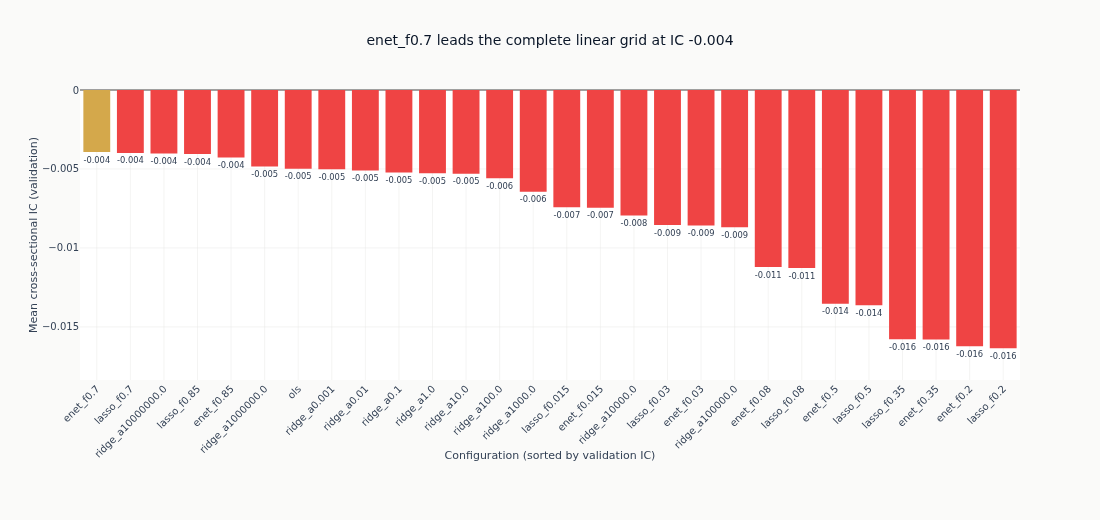

In [37]:
_names = [r["config"]["config_name"] for r in complete]
_ics = [r["ic_mean"] for r in complete]
_leader = best["config"]["config_name"]
_lead_ic = best["ic_mean"]
_bar_colors = [
    COLORS["amber"] if n == _leader else (COLORS["blue"] if ic >= 0 else COLORS["negative"])
    for n, ic in zip(_names, _ics, strict=False)
]
fig_ic = go.Figure(
    go.Bar(
        x=_names,
        y=_ics,
        marker_color=_bar_colors,
        text=[f"{v:+.3f}" for v in _ics],
        textposition="outside",
        cliponaxis=False,
    )
)
fig_ic.update_layout(
    title=f"{_pretty_config(_leader)} leads the complete linear grid at IC {_lead_ic:+.3f}",
    template="ml4t",
    height=520,
    width=1100,
    showlegend=False,
    margin=dict(t=90, b=140),
)
fig_ic.update_xaxes(title_text="Configuration (sorted by validation IC)", tickangle=-45)
fig_ic.update_yaxes(title_text="Mean cross-sectional IC (validation)", zeroline=True)
fig_ic.show()

### Ridge regularization sweep

The Ridge curve isolates how the measured validation IC changes with penalty
strength. Its title is derived from the current points, including whether the
path is increasing, decreasing, or non-monotonic.

In [38]:
_ridge = sorted(
    (float(r["config"]["config_name"].split("_a")[1]), r["ic_mean"])
    for r in complete
    if r["config"]["config_name"].startswith("ridge_a")
)
_logalpha = [np.log10(a) for a, _ in _ridge]
_ridge_ic = [ic for _, ic in _ridge]
_peak_i = int(np.argmax(_ridge_ic)) if _ridge_ic else 0

In [39]:
fig_alpha = go.Figure(
    go.Scatter(
        x=_logalpha,
        y=_ridge_ic,
        mode="lines+markers",
        line=dict(color=COLORS["blue"], width=2),
        marker=dict(size=8, color=COLORS["blue"]),
        name="Ridge IC",
    )
)
if _ridge_ic:
    fig_alpha.add_trace(
        go.Scatter(
            x=[_logalpha[_peak_i]],
            y=[_ridge_ic[_peak_i]],
            mode="markers",
            marker=dict(size=15, color=COLORS["amber"]),
            showlegend=False,
        )
    )
_peak_exp = int(round(_logalpha[_peak_i])) if _ridge_ic else 0

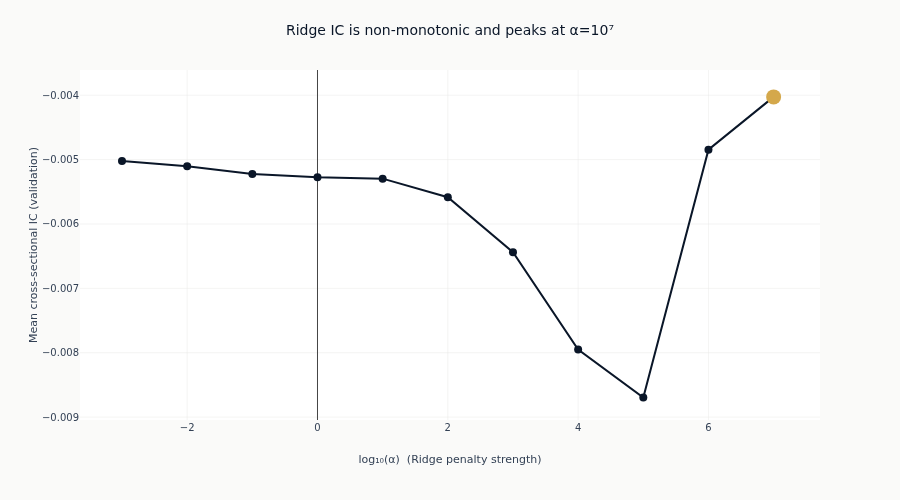

In [40]:
_ridge_steps = np.diff(_ridge_ic)
if np.all(_ridge_steps >= 0):
    _ridge_title = (
        f"Ridge IC rises with shrinkage and peaks at α=10{str(_peak_exp).translate(_SUP)}"
    )
elif np.all(_ridge_steps <= 0):
    _ridge_title = (
        f"Ridge IC falls with shrinkage and peaks at α=10{str(_peak_exp).translate(_SUP)}"
    )
else:
    _ridge_title = f"Ridge IC is non-monotonic and peaks at α=10{str(_peak_exp).translate(_SUP)}"
fig_alpha.update_layout(
    title=_ridge_title,
    template="ml4t",
    height=500,
    width=900,
    showlegend=False,
    margin=dict(t=70),
)
fig_alpha.update_xaxes(title_text="log₁₀(α)  (Ridge penalty strength)")
fig_alpha.update_yaxes(title_text="Mean cross-sectional IC (validation)", zeroline=True)
fig_alpha.show()

## 5. Register Results

Each config is registered in the unified registry with its predictions,
IC metrics, and full provenance (training hash = SHA256 of config + label
+ features + folds). Identical configs produce the same hash - re-running
updates rather than duplicates.

In [41]:
def _registration_metrics(result: dict) -> dict[str, float | int]:
    """Combine point estimates with the explicit 21-session uncertainty pack."""
    return {
        "ic_mean": result["ic_mean"],
        "ic_std": result["ic_std"],
        "ic_n_days": result["ic_n_days"],
        **_compute_ic_uncertainty_metrics(
            result["predictions"], expected_ic_dates, date_col, entity_col
        ),
    }

In [42]:
def _register_result(result: dict) -> None:
    if result.get("cached"):
        return
    cfg = result["config"]
    spec = result["training_spec"]
    if training_hash_from_spec(spec) != result["training_hash"]:
        raise ValueError(f"{cfg['config_name']}: training identity changed before registration")
    _require_isolated_registry(CASE_DIR)
    t_hash = register_training_run(
        CASE_STUDY_ID,
        spec=spec,
        entry_point="06_linear",
        started_at=result.get("started_at"),
        elapsed_s=result.get("elapsed_s"),
    )
    train_dir = CASE_DIR / "run_log/training" / t_hash
    coefs = result.get("coefficients", [])
    if coefs:
        _require_isolated_registry(CASE_DIR)
        pd.DataFrame(coefs).to_parquet(train_dir / "coefficients.parquet", index=False)
    _require_isolated_registry(CASE_DIR)
    prediction_hash = register_prediction_set(
        CASE_STUDY_ID,
        t_hash,
        split=PREDICTION_SPLIT,
        predictions=result["predictions"],
        task_type=mds.task_type,
        class_values=mds.class_values or None,
        metrics=_registration_metrics(result),
    )
    if prediction_hash != prediction_hash_from_parts(t_hash, None, PREDICTION_SPLIT):
        raise ValueError(f"{cfg['config_name']}: registry returned a forged prediction hash")
    print(f"  registered {cfg['config_name']:25s}  IC={result['ic_mean']:+.4f}")

In [43]:
for result in complete:
    _register_result(result)

## 6. Key Takeaways

The closing summary is generated from the complete current validation results so
its winner, sign, and regularization comparison cannot preserve a stale run.

In [44]:
_positive = sum(result["ic_mean"] > 0 for result in complete)
_direction = "positive" if _lead_ic > 0 else "negative" if _lead_ic < 0 else "zero"
_summary = f"""
### Measured linear-model result

- **Leader:** `{_leader}` reaches daily IC **{_lead_ic:+.4f}** across **{expected_ic_days}** dates,
  so the leading validation association is **{_direction}**.
- **Breadth:** **{_positive}/{len(complete)}** complete configurations have positive IC; the range
  runs from **{complete[-1]["ic_mean"]:+.4f}** to **{_lead_ic:+.4f}**.
- **Ridge path:** {_ridge_title.rstrip(".")}; the measured peak IC is
  **{_ridge_ic[_peak_i]:+.4f}**.
- **Next test:** gradient boosting evaluates whether interactions among IV, VRP, and realized
  volatility improve on this measured linear benchmark.
"""
display(Markdown(_summary))


### Measured linear-model result

- **Leader:** `enet_f0.7` reaches daily IC **-0.0039** across **484** dates,
  so the leading validation association is **negative**.
- **Breadth:** **0/28** complete configurations have positive IC; the range
  runs from **-0.0163** to **-0.0039**.
- **Ridge path:** Ridge IC is non-monotonic and peaks at α=10⁷; the measured peak IC is
  **-0.0040**.
- **Next test:** gradient boosting evaluates whether interactions among IV, VRP, and realized
  volatility improve on this measured linear benchmark.



**Next**: `07_gbm.py` tests gradient boosting across a 15-config grid (tree depth ×
loss) to evaluate non-linear feature interactions.